In [1]:
import subprocess
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"], check=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 70.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


CompletedProcess(args=['python', '-m', 'spacy', 'download', 'en_core_web_sm'], returncode=0)

In [3]:
import spacy
from spacy import displacy
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

nlp = spacy.load("en_core_web_sm")

In [8]:
texts = [
    "Apple Inc. was founded by Steve Jobs in Cupertino, California in 1976.",
    "Elon Musk announced that Tesla will open a new factory in Berlin, Germany by 2025.",
    "The United Nations held a summit in New York to discuss climate policy in September.",
    "Amazon acquired Whole Foods for $13.7 billion in a deal approved by the FTC.",
    "NASA's Artemis mission aims to return astronauts to the Moon by 2026."
]

In [9]:
for text in texts[:2]:
    doc = nlp(text)
    html = displacy.render(doc, style="ent", jupyter=False, page=False)
    display(HTML(html))

In [10]:
records = []
for i, text in enumerate(texts):
    doc = nlp(text)
    for ent in doc.ents:
        records.append({
            "text_id": i + 1,
            "entity": ent.text,
            "label": ent.label_,
            "description": spacy.explain(ent.label_)
        })

df_ents = pd.DataFrame(records)

In [11]:
df_ents

,text_id,entity,label,description
0,1,Apple Inc.,ORG,"Companies, agencies, institutions, etc."
1,1,Steve Jobs,PERSON,"People, including fictional"
2,1,Cupertino,GPE,"Countries, cities, states"
3,1,California,GPE,"Countries, cities, states"
4,1,1976,DATE,Absolute or relative dates or periods
5,2,Elon Musk,PERSON,"People, including fictional"
6,2,Tesla,ORG,"Companies, agencies, institutions, etc."
7,2,Berlin,GPE,"Countries, cities, states"
8,2,Germany,GPE,"Countries, cities, states"
9,2,2025,DATE,Absolute or relative dates or periods


/tmp/ipykernel_55/1959625968.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


<Axes: xlabel='label'>

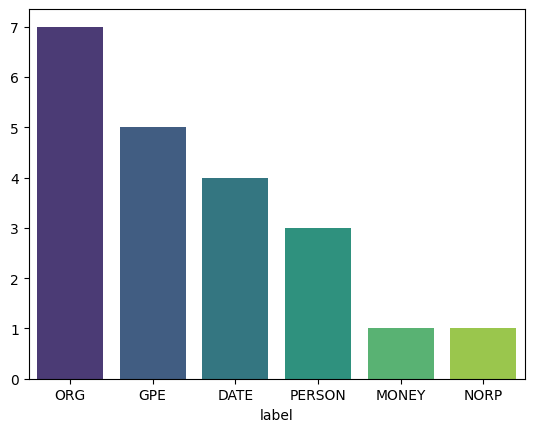

In [12]:
label_counts = df_ents["label"].value_counts()
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")

In [14]:
for label in df_ents["label"].unique():
    top = df_ents[df_ents["label"] == label]["entity"].value_counts().head(5)

In [15]:
def extract_entities(text: str) -> dict:
    doc = nlp(text)
    result = {}
    for ent in doc.ents:
        result.setdefault(ent.label_, []).append(ent.text)
    return result

In [16]:
ents = len(doc.ents)
tokens = len([t for t in doc if not t.is_space and not t.is_punct])
density = round(ents / tokens * 100, 1)

In [17]:
print(f"Total entities found: {len(df_ents)}")
print(f"Unique entity types : {df_ents['label'].nunique()}")

Total entities found: 21
Unique entity types : 6
